In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
X=6*np.random.rand(100,1)-3
y=0.5*X**2+1.5*X+2+np.random.randn(100,1) ##quadratic equation used y=ax+bx^2+c with outlier

Text(0, 0.5, 'Y')

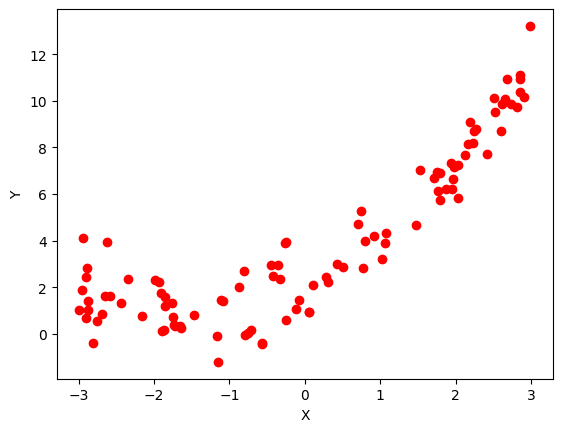

In [13]:
plt.scatter(X,y,color='r')
plt.xlabel('X')
plt.ylabel('Y')

In [14]:
##implement with simple linear regtression first
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [16]:
regression_1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
score

0.3966530450669453

Text(0, 0.5, 'Y')

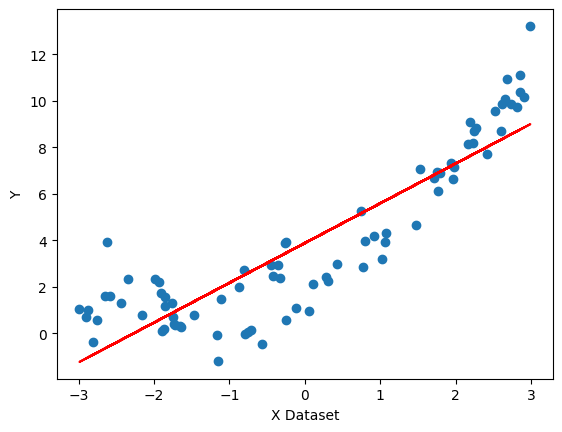

In [18]:
##lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [19]:
#solving this problem with polynomial regression
from sklearn.preprocessing import PolynomialFeatures

In [21]:
poly=PolynomialFeatures(degree=2,include_bias=True)
##adds an x^2 term extra 
#include 1, x and x^2 for model training purposes
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
##test data is unaware about technique used to transform training data

In [22]:
X_train_poly

array([[ 1.00000000e+00,  8.04530487e-01,  6.47269304e-01],
       [ 1.00000000e+00, -2.87771320e+00,  8.28123324e+00],
       [ 1.00000000e+00, -8.11747147e-01,  6.58933431e-01],
       [ 1.00000000e+00,  1.01884749e+00,  1.03805020e+00],
       [ 1.00000000e+00,  4.23297373e-01,  1.79180666e-01],
       [ 1.00000000e+00, -2.90555865e+00,  8.44227106e+00],
       [ 1.00000000e+00, -1.89353446e+00,  3.58547276e+00],
       [ 1.00000000e+00,  2.86069507e+00,  8.18357627e+00],
       [ 1.00000000e+00,  2.60939031e+00,  6.80891777e+00],
       [ 1.00000000e+00, -1.74437303e+00,  3.04283727e+00],
       [ 1.00000000e+00, -2.58709015e+00,  6.69303546e+00],
       [ 1.00000000e+00,  2.85313938e+00,  8.14040432e+00],
       [ 1.00000000e+00, -1.11424124e+00,  1.24153355e+00],
       [ 1.00000000e+00, -7.51858325e-01,  5.65290940e-01],
       [ 1.00000000e+00,  2.23826468e+00,  5.00982880e+00],
       [ 1.00000000e+00, -5.71970088e-01,  3.27149782e-01],
       [ 1.00000000e+00, -2.65140997e+00

In [23]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8871055801655285


In [26]:
regression.coef_

array([[0.        , 1.62462106, 0.48366923]])

In [27]:
regression.intercept_

array([2.18947729])

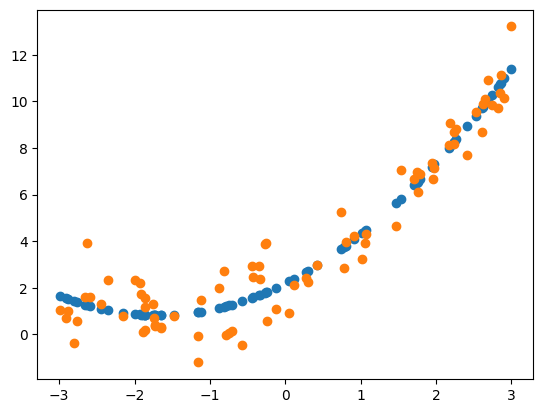

In [30]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)


In [31]:
poly=PolynomialFeatures(degree=3,include_bias=True)
##adds an x^2 term extra 
#include 1, x and x^2 for model training purposes
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
##test data is unaware about technique used to transform training data

In [32]:
X_train_poly

array([[ 1.00000000e+00,  8.04530487e-01,  6.47269304e-01,
         5.20747888e-01],
       [ 1.00000000e+00, -2.87771320e+00,  8.28123324e+00,
        -2.38310142e+01],
       [ 1.00000000e+00, -8.11747147e-01,  6.58933431e-01,
        -5.34887333e-01],
       [ 1.00000000e+00,  1.01884749e+00,  1.03805020e+00,
         1.05761484e+00],
       [ 1.00000000e+00,  4.23297373e-01,  1.79180666e-01,
         7.58467053e-02],
       [ 1.00000000e+00, -2.90555865e+00,  8.44227106e+00,
        -2.45295137e+01],
       [ 1.00000000e+00, -1.89353446e+00,  3.58547276e+00,
        -6.78921623e+00],
       [ 1.00000000e+00,  2.86069507e+00,  8.18357627e+00,
         2.34107163e+01],
       [ 1.00000000e+00,  2.60939031e+00,  6.80891777e+00,
         1.77671240e+01],
       [ 1.00000000e+00, -1.74437303e+00,  3.04283727e+00,
        -5.30784326e+00],
       [ 1.00000000e+00, -2.58709015e+00,  6.69303546e+00,
        -1.73154861e+01],
       [ 1.00000000e+00,  2.85313938e+00,  8.14040432e+00,
      

In [33]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8827661055769419


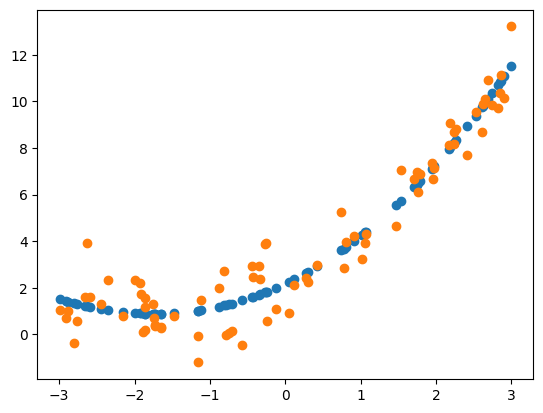

In [34]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

##Pipeline Concepts


In [38]:
from sklearn.pipeline import Pipeline

def poly_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    poly_features=PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new=poly_regression.predict(X_new)
    ##plotting prediction line
    plt.plot(X_new,y_pred_new,'r',label="Degree "+str(degree), linewidth=3)
    plt.plot(X_train,y_train,"b.",linewidth=3)
    plt.plot(X_test,y_test,"g.",linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])

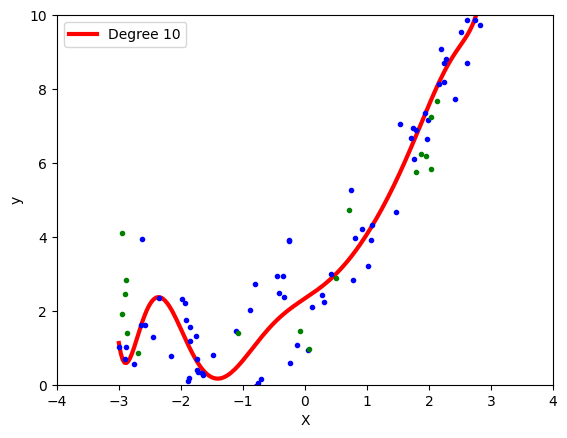

In [44]:
poly_regression(10)